# Pool-based Multilabel Active Learning - Getting Started

> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try to restart the runtime (Ctrl + M) under Runtime -> Restart session.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](<colab_link>)

**Notebook Dependencies**

Uncomment the following cell to install all dependencies for this tutorial.

In [1]:
# !pip install scikit-activeml[opt] torch torchvision tqdm

The goal of this tutorial is to show a clean end-to-end workflow for pool-based multilabel active learning with `scikit-activeml`.

We will:
- generate a synthetic multilabel data set,
- compare several multilabel-compatible query strategies,
- evaluate them over repeated random train/test splits, and
- report mean learning curves together with standard errors.

To make the example more useful, we compare two classifier backends:
- a neural multilabel model wrapped with `SkorchClassifier`, and
- a native multilabel `RandomForestClassifier` from `scikit-learn` wrapped with `SklearnClassifier`.


In [ ]:
import warnings
from math import sqrt

import matplotlib as mlp
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler    
from sklearn.datasets import make_multilabel_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from tqdm.notebook import tqdm

from skactiveml.classifier import (
    ParzenWindowClassifier,
    SklearnClassifier,
    SkorchClassifier,
)
from skactiveml.pool import (
    LabelCardinalityInconsistency,
    MaxLossReductionMaxConfidence,
    ProbCover,
    RandomSampling,
)
from skactiveml.utils import MISSING_LABEL, call_func

warnings.filterwarnings("ignore")
mlp.rcParams["figure.facecolor"] = "white"
device = "cuda" if torch.cuda.is_available() else "cpu"


## Experiment Setup
We use repeated random train/test splits to obtain smoother learning curves. Each repetition starts with a small random seed set of fully labeled samples, after which the query strategy selects additional unlabeled samples in batches. We generate a synthetic multilabel data set with `make_multilabel_classification`. In multilabel classification, each sample is represented by a binary indicator vector because multiple classes can be active at the same time. For evaluation, we keep a held-out test split and only reveal labels from the pool when the active learner queries them.


In [3]:
seed = 42
n_samples = 1000
n_features = 5
n_classes = 20
test_size = 0.3
n_cycles = 20
batch_size = 30
initial_labeled_samples = 2 * batch_size
n_repetitions = 10
classes = [[0, 1] for _ in range(n_classes)]


## Classifiers, Query Strategies, and Metrics
The two classifier factory functions below share the same multilabel target representation, namely `classes=[[0, 1], ..., [0, 1]]`. The query strategies are restricted to strategies that are compatible with both classifier backends used in this tutorial.


In [ ]:
def topk_accuracy(probas, targets, topk=1):
    """Return the fraction of samples for which one of the true labels is among the top-k predicted labels."""
    probas = np.asarray(probas)
    topk_pred_indices = np.argsort(-probas, axis=1)[:, :topk]
    return np.mean(
        np.any(
            targets[np.arange(targets.shape[0])[:, None], topk_pred_indices],
            axis=1,
        )
    )


class ClassificationModule(nn.Module):
    def __init__(self, n_features, n_classes, n_hidden_units=128):
        super().__init__()
        self.linear_1 = nn.Linear(n_features, n_hidden_units)
        self.linear_2 = nn.Linear(n_hidden_units, n_classes)
        self.activation = nn.ReLU()

    def forward(self, x):
        x_embed = self.linear_1(x)
        logits = self.linear_2(self.activation(x_embed))
        return logits, x_embed


classifier_factory_functions = {
    "Skorch MLP": lambda random_state: SkorchClassifier(
        module=ClassificationModule,
        criterion=nn.BCEWithLogitsLoss,
        sample_dtype=np.float32,
        forward_outputs={"proba": (0, nn.Sigmoid()), "emb": (1, None)},
        neural_net_param_dict={
            "module__n_features": n_features,
            "module__n_hidden_units": 128,
            "module__n_classes": n_classes,
            "max_epochs": 40,
            "batch_size": 32,
            "lr": 0.001,
            "optimizer": torch.optim.Adam,
            "verbose": 0,
            "device": device,
            "train_split": False,
            "iterator_train__shuffle": True,
        },
        classes=classes,
        missing_label=MISSING_LABEL,
        random_state=random_state,
    ),
    "RandomForest": lambda random_state: SklearnClassifier(
        estimator=RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=random_state,
        ),
        classes=classes,
        missing_label=MISSING_LABEL,
        proba_format="array",
        random_state=random_state,
    ),
}

query_strategy_factory_functions = {
    "RandomSampling": lambda random_state: RandomSampling(random_state=random_state),
    "ProbCover": lambda random_state: ProbCover(random_state=random_state),
    "LabelCardinalityInconsistency": lambda random_state: LabelCardinalityInconsistency(
        random_state=random_state
    ),
    "MMC": lambda random_state: MaxLossReductionMaxConfidence(
        random_state=random_state
    ),
}


def build_discriminator(random_state):
    return ParzenWindowClassifier(
        classes=[0, 1],
        metric="rbf",
        metric_dict={"gamma": "mean"},
        random_state=random_state,
    )


def evaluate_classifier(clf, X_eval, Y_eval):
    probas = clf.predict_proba(X_eval)
    y_pred = clf.predict(X_eval)
    return {
        "Macro F1": f1_score(Y_eval, y_pred, average="macro", zero_division=0),
        "Top-1 Hit Rate": topk_accuracy(probas, Y_eval, topk=1),
    }

def run_repetition(repetition_seed):
    X, Y_true = make_multilabel_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_classes=n_classes,
        n_labels=3,
        random_state=0,
    )
    X = StandardScaler().fit_transform(X)

    X_pool, X_test, Y_pool_true, Y_test = train_test_split(
        X,
        Y_true,
        test_size=test_size,
        random_state=0,
        shuffle=True,
    )

    repetition_results = {
        clf_name: {
            qs_name: {"Macro F1": [], "Top-1 Hit Rate": []}
            for qs_name in query_strategy_factory_functions
        }
        for clf_name in classifier_factory_functions
    }

    rng = np.random.default_rng(repetition_seed)
    initial_idx = rng.choice(
        len(X_pool), size=initial_labeled_samples, replace=False
    )

    for clf_name, clf_factory in classifier_factory_functions.items():
        for qs_name, qs_factory in query_strategy_factory_functions.items():
            torch.manual_seed(repetition_seed)
            clf = clf_factory(random_state=repetition_seed)
            qs = qs_factory(random_state=repetition_seed)
            discriminator = build_discriminator(random_state=repetition_seed)

            Y_pool = np.full(Y_pool_true.shape, MISSING_LABEL, dtype=float)
            Y_pool[initial_idx] = Y_pool_true[initial_idx]
            clf.fit(X_pool, Y_pool)

            metrics = evaluate_classifier(clf, X_test, Y_test)
            for metric_name, value in metrics.items():
                repetition_results[clf_name][qs_name][metric_name].append(value)

            for _ in range(n_cycles):
                query_idx = call_func(
                    qs.query,
                    X=X_pool,
                    y=Y_pool,
                    batch_size=batch_size,
                    clf=clf,
                    fit_clf=False,
                    discriminator=discriminator,
                )
                Y_pool[query_idx] = Y_pool_true[query_idx]
                clf.fit(X_pool, Y_pool)

                metrics = evaluate_classifier(clf, X_test, Y_test)
                for metric_name, value in metrics.items():
                    repetition_results[clf_name][qs_name][metric_name].append(value)

    return repetition_results


### Evaluate Sampling Strategies
We now repeat the experiment several times. The resulting learning curves have length `n_cycles + 1`, where cycle 0 corresponds to the initially labeled seed set.


In [5]:
results = {
    clf_name: {
        qs_name: {"Macro F1": [], "Top-1 Hit Rate": []}
        for qs_name in query_strategy_factory_functions
    }
    for clf_name in classifier_factory_functions
}

for repetition in tqdm(range(n_repetitions), desc="Repetitions"):
    repetition_seed = seed + repetition
    repetition_results = run_repetition(repetition_seed)

    for clf_name in classifier_factory_functions:
        for qs_name in query_strategy_factory_functions:
            for metric_name in ["Macro F1", "Top-1 Hit Rate"]:
                results[clf_name][qs_name][metric_name].append(
                    repetition_results[clf_name][qs_name][metric_name]
                )


Repetitions:   0%|          | 0/10 [00:00<?, ?it/s]

## Plot Learning Curves with Standard Errors
For every classifier and query strategy, we average the learning curves over all repetitions. The shaded regions show one standard error of the mean.


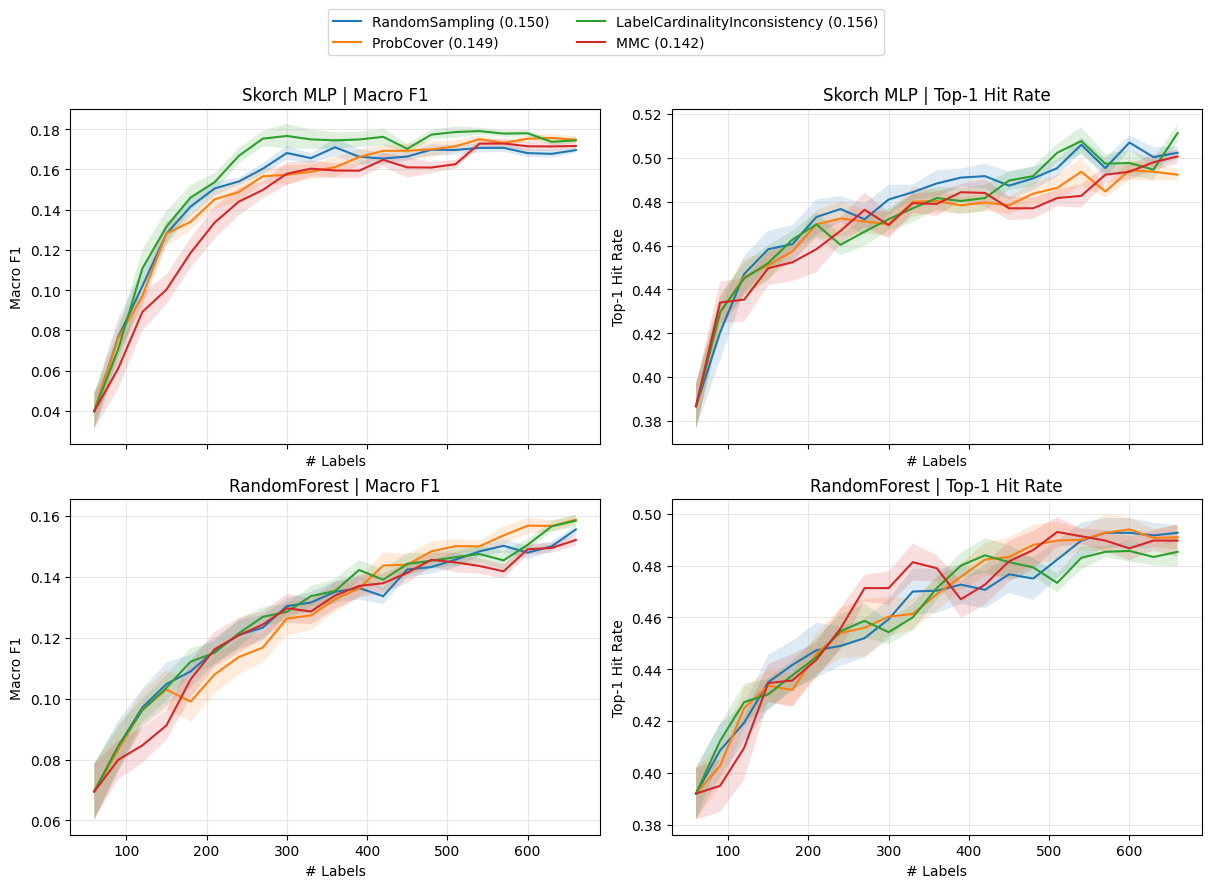

In [7]:
metric_names = ["Macro F1", "Top-1 Hit Rate"]
cycle_axis = initial_labeled_samples + np.arange(0, batch_size * (n_cycles+1), batch_size)
fig, axes = plt.subplots(
    len(classifier_factory_functions),
    len(metric_names),
    figsize=(12, 4 * len(classifier_factory_functions)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_2d(axes)

for row_idx, clf_name in enumerate(classifier_factory_functions):
    for col_idx, metric_name in enumerate(metric_names):
        ax = axes[row_idx, col_idx]
        for qs_name in query_strategy_factory_functions:
            curves = np.asarray(results[clf_name][qs_name][metric_name])
            mean_curve = curves.mean(axis=0)
            if curves.shape[0] > 1:
                stderr_curve = curves.std(axis=0, ddof=1) / sqrt(curves.shape[0])
            else:
                stderr_curve = np.zeros_like(mean_curve)
            label = f"{qs_name} ({mean_curve.mean():.3f})"
            ax.plot(cycle_axis, mean_curve, label=label)
            ax.fill_between(
                cycle_axis,
                mean_curve - stderr_curve,
                mean_curve + stderr_curve,
                alpha=0.15,
            )
        ax.set_title(f"{clf_name} | {metric_name}")
        ax.set_xlabel("# Labels")
        ax.set_ylabel(metric_name)
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=2)
plt.show()


The `RandomForest` curve provides a native multilabel `scikit-learn` baseline, while the `Skorch MLP` demonstrates how to plug in a neural multilabel model. You can now swap in additional classifiers or query strategies while keeping the same repeated-evaluation structure.
